# Libraries

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Rescaling
from keras.models import Sequential
from keras.optimizers import Adam

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Load data

Load it in grayscale.

In [4]:
# It is important to keep shuffle to False so we can have consistency when parsing the images
# We will shuffle on training
# If using image_dataset_from_directory, batch size is decided here instead of during `fit`

train_ds = tf.keras.utils.image_dataset_from_directory(
    './x-rays//train/',
    color_mode='grayscale',
    batch_size=32,
    shuffle=False
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    './x-rays//validation/',
    color_mode='grayscale',
    batch_size=32,
    shuffle=False
)

Found 351 files belonging to 3 classes.
Found 90 files belonging to 3 classes.


In [5]:
# Manually extract true labels from the validation dataset
y_val = np.concatenate([y for _, y in val_ds], axis=0)

In [6]:
class_names = train_ds.class_names
class_names

['COVID-19', 'HEALTHY', 'PNEUMONIA']

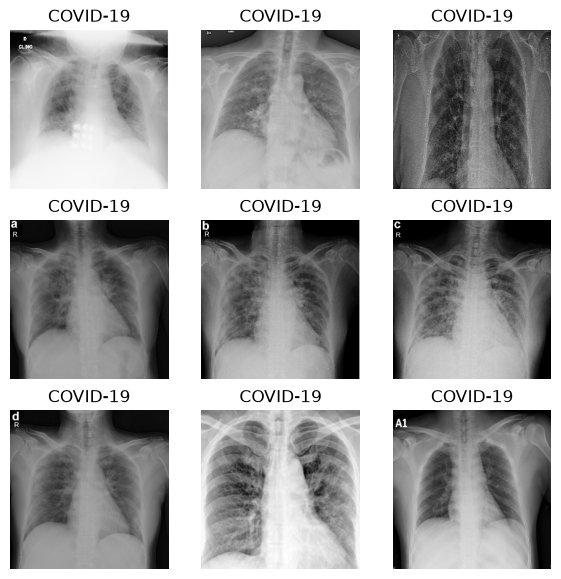

In [7]:
# Display image samples
plt.figure(figsize=(7, 7))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')

In [8]:
# Image shapes
images[i].shape

TensorShape([256, 256, 1])

# Functions

In [9]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import glob
import os

def generate_submission(model, leaderboard_folder, submission_path, is_grayscale=False):
    paths = sorted(glob.glob(os.path.join(leaderboard_folder, "*")))
    # sort by numeric part of the filename
    paths = sorted(paths, key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))
    imgs = []
    names = []

    for p in paths:
        if is_grayscale:
            img = load_img(p, target_size=(256, 256), color_mode='grayscale')  # CAST!
        else:
            img = load_img(p, target_size=(256, 256))  # CAST!
        names.append(int(os.path.splitext(os.path.basename(p))[0]))
        imgs.append(img_to_array(img))

    X_lb = np.array(imgs)
    predictions = model.predict(X_lb, verbose=0)
    if predictions.shape[1] > 1:
        predictions = predictions.argmax(axis=1)

    submission_df = pd.DataFrame({
        'id': names,
        'prediction': predictions
    }).sort_values('id')

    submission_df.to_csv(submission_path, index=False)

# CNN

## Grayscale

Keras can directly load data from a structure of directories, we don't need the pandas DataFrame we were using before.

The following example is not working well. Improve it! For example, adding more convolutional layer and/or more filters, etc.

In [10]:
cnn_model = Sequential([
    Input(shape=(256, 256, 1)),
    Rescaling(1./255),
    Conv2D(filters=2, kernel_size=2, strides=1, activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 255, 255, 2)    │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32258)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     1,032,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,032,397 (3.94 MB)

 Trainable params: 1,032,397 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
cnn_model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4017 - loss: 3.2044 - val_accuracy: 0.3333 - val_loss: 1.1239
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3419 - loss: 1.0582 - val_accuracy: 0.3556 - val_loss: 1.0846
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5926 - loss: 1.0341 - val_accuracy: 0.4889 - val_loss: 1.0729
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6638 - loss: 1.0079 - val_accuracy: 0.5333 - val_loss: 1.0643
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6838 - loss: 0.9740 - val_accuracy: 0.5111 - val_loss: 1.0534


In [ ]:
loss, acc = cnn_model.evaluate(val_ds, verbose=0)
print('Validation accuracy:', round(acc, 2))

Validation accuracy: 0.33


In [ ]:
# Keras returns predicted probabilities by default

y_val_pred_probs = cnn_model.predict(val_ds, verbose=0)
y_val_pred_probs[:5]

array([[0.35205898, 0.3065102 , 0.34143093],
       [0.35205898, 0.3065102 , 0.34143093],
       [0.35205898, 0.3065102 , 0.34143093],
       [0.35205898, 0.3065102 , 0.34143093],
       [0.35205898, 0.3065102 , 0.34143093]], dtype=float32)

In [ ]:
# Convert probabilities to class predictions
y_val_pred = y_val_pred_probs.argmax(axis=1)
y_val_pred[:5]

array([0, 0, 0, 0, 0])

In [ ]:
print(classification_report(y_val, y_val_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.33      1.00      0.50        30
           1       0.00      0.00      0.00        30
           2       0.00      0.00      0.00        30

    accuracy                           0.33        90
   macro avg       0.11      0.33      0.17        90
weighted avg       0.11      0.33      0.17        90



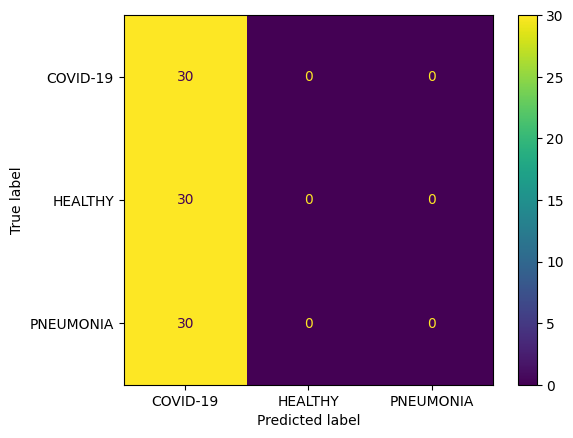

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
plt.xticks(range(3), val_ds.class_names)
plt.yticks(range(3), val_ds.class_names)
plt.show()

## RGB

Same example as before, but working with RGB images instead.

In this case, we just need to specify we are receiving an input of (256, 256, 3).

In [ ]:
train_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    '../../data/x-rays/train/',
    batch_size=32,
    shuffle=False
)
val_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    '../../data/x-rays/validation/',
    batch_size=32,
    shuffle=False
)

Found 351 files belonging to 3 classes.
Found 90 files belonging to 3 classes.


In [ ]:
cnn_rgb_model = Sequential([
    Input(shape=(256, 256, 3)),
    Rescaling(1./255),
    Conv2D(filters=3, kernel_size=2, strides=1, activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

cnn_rgb_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
cnn_rgb_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 255, 255, 3)    │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 127, 127, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 48387)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │     1,548,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,548,554 (5.91 MB)

 Trainable params: 1,548,554 (5.91 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_rgb_model.fit(train_rgb_ds, validation_data=val_rgb_ds, epochs=5)

Epoch 1/5


/home/ibci/.local/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.3618 - loss: 54.9354 - val_accuracy: 0.3333 - val_loss: 8.2220
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.0285 - loss: 17.7562 - val_accuracy: 0.3333 - val_loss: 8.8817
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.3276 - loss: 5.8417 - val_accuracy: 0.3444 - val_loss: 4.6475
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.2450 - loss: 6.5220 - val_accuracy: 0.4889 - val_loss: 2.5733
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.0940 - loss: 6.9651 - val_accuracy: 0.3889 - val_loss: 2.7629


In [ ]:
loss, acc = cnn_rgb_model.evaluate(val_rgb_ds, verbose=0)
print('Validation accuracy:', round(acc, 2))

Validation accuracy: 0.39


In [ ]:
# Keras returns predicted probabilities by default

y_val_rgb_pred_probs = cnn_rgb_model.predict(val_rgb_ds, verbose=0)
y_val_rgb_pred_probs[:5]

array([[1.1024842e-02, 9.8897517e-01, 2.2283919e-08],
       [4.8364368e-03, 9.9516350e-01, 3.5585015e-10],
       [6.1610639e-03, 9.9383867e-01, 2.8301903e-07],
       [7.0733489e-03, 9.9292642e-01, 2.5667882e-07],
       [4.3644346e-03, 9.9563545e-01, 1.2052962e-07]], dtype=float32)

In [ ]:
# Convert probabilities to class predictions
y_val_rgb_pred = y_val_rgb_pred_probs.argmax(axis=1)
y_val_rgb_pred[:5]

array([1, 1, 1, 1, 1])

In [ ]:
# Extract true labels from the validation dataset
y_val = np.concatenate([y for _, y in val_ds], axis=0)

In [ ]:
print(classification_report(y_val, y_val_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.33      1.00      0.50        30
           1       0.00      0.00      0.00        30
           2       0.00      0.00      0.00        30

    accuracy                           0.33        90
   macro avg       0.11      0.33      0.17        90
weighted avg       0.11      0.33      0.17        90



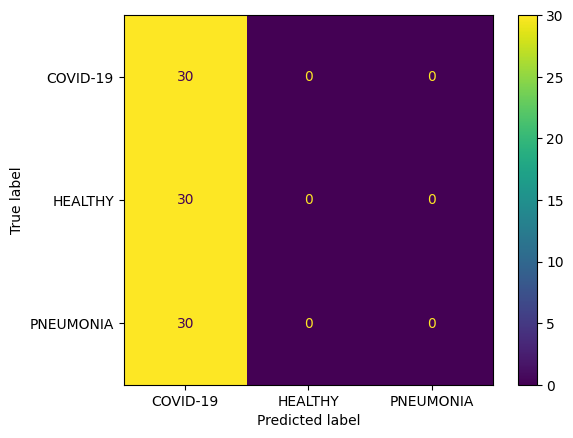

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
plt.xticks(range(3), val_ds.class_names)
plt.yticks(range(3), val_ds.class_names)
plt.show()

## Test

In [ ]:
# Grayscale
test_ds = tf.keras.utils.image_dataset_from_directory(
    '../../data/x-rays/validation/',
    color_mode='grayscale',
    batch_size=32,
    shuffle=False
)

# RGB
test_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    '../../data/x-rays/validation/',
    batch_size=32,
    shuffle=False
)

Found 90 files belonging to 3 classes.
Found 90 files belonging to 3 classes.


In [ ]:
# Extract true labels from the validation dataset
y_test = np.concatenate([y for _, y in test_ds], axis=0)

### Grayscale model

In [ ]:
# Keras returns predicted probabilities by default

y_test_pred_probs = cnn_model.predict(test_ds, verbose=0)
y_test_pred = y_test_pred_probs.argmax(axis=1)

In [ ]:
print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.33      1.00      0.50        30
           1       0.00      0.00      0.00        30
           2       0.00      0.00      0.00        30

    accuracy                           0.33        90
   macro avg       0.11      0.33      0.17        90
weighted avg       0.11      0.33      0.17        90



### RGB model

In [ ]:
# Keras returns predicted probabilities by default

y_test_rgb_pred_probs = cnn_rgb_model.predict(test_rgb_ds, verbose=0)
y_test_rgb_pred = y_test_rgb_pred_probs.argmax(axis=1)

In [ ]:
print(classification_report(y_test, y_test_rgb_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.35      0.97      0.52        30
           2       0.75      0.20      0.32        30

    accuracy                           0.39        90
   macro avg       0.37      0.39      0.28        90
weighted avg       0.37      0.39      0.28        90



## Submission

In [13]:
generate_submission(
    cnn_model,
    leaderboard_folder='./x-rays/leaderboard',
    submission_path='./x-rays/submission_prueba.csv',
    is_grayscale=True
)

In [ ]:
generate_submission(
    cnn_rgb_model,
    leaderboard_folder='../../data/x-rays/leaderboard',
    submission_path='../../data/x-rays/submission_cnn_rgb.csv',
    is_grayscale=False
)